# Analising NiSi XRD data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve

import plotly.graph_objects as go

from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
API_KEY = "Nc1dTFzE1dg6gchvs0voTKE07XuuXIKW"


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

### read file

In [2]:
# file_path = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Si\Data\Stückchen\XRD\ESPIN\W1_9_3_1050C_2min_in-plane_GIXRD_detector_scan.xy"
# file_path = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Si\Data\Stückchen\XRD\ESPIN\W1_12_5_700C_120s_in-plane_GIXRD_detector_scan.xy"
# file_path = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Si\Data\Stückchen\XRD\ESPIN\W1_9_3_1050C_2min_in-plane_GIXRD_detector_scan.xy"
# file_path = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Si\Data\Stückchen\XRD\ESPIN\W1_12_5_700C_120s_in-plane_GIXRD_detector_scan.xy"
# file_path = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Si\Data\Stückchen\XRD\02182026_Ni2Si_900grad_.xy"
file_path = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Si\Data\Stückchen\XRD\02202026_Ni2Si_800grad_.xy"

# data = pd.read_csv(file_path, delimiter="\t", skiprows=2, header=0, names=['Angle', 'Intensity'])
data = pd.read_csv(file_path, delimiter=" ", skiprows=1, header=None, names=['Angle', 'Intensity'])

filename = os.path.basename(file_path)
name = filename.split("_", 7)[3:7]
name = " ".join(name)
print(name)

print(data.info())

.xy
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6001 entries, 0 to 6000
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Angle      6001 non-null   float64
 1   Intensity  6001 non-null   float64
dtypes: float64(2)
memory usage: 93.9 KB
None


In [3]:
# remove offsett by main Ni2Si peak
# data['Angle'] = data['Angle'] + 1.4319  # 700C
# data['Angle'] = data['Angle'] + 0.1919  # 1050C

In [4]:
from processXRD import process_XRD_data

# processed_data, peak_angles = process_XRD_data(data, roi=False, baseline_params={'lam': 1e7, 'p': 0.0001, 'niter': 10}, peak_params={'prominence': 0.04, 'width': 5})
processed_data, peak_angles = process_XRD_data(data, roi=True, roi_start=64.5, roi_end=66.5, baseline_params={'lam': 1e7, 'p': 0.0001, 'niter': 10}, peak_params={'prominence': 0.04, 'width': 5})

c:\Users\lhage\Documents\VSCode\Master_data\XRD\processXRD.py:17: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)
c:\Users\lhage\Documents\VSCode\Master_data\XRD\processXRD.py:17: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


### plot basic spectra starting point

C:\Users\lhage\AppData\Local\Temp\ipykernel_14648\2548002416.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


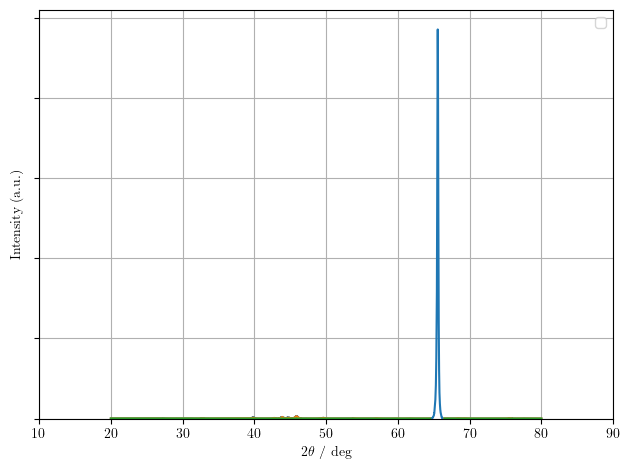

In [5]:
fig, ax = plt.subplots()
ax.plot(data['Angle'], data['Intensity'])
# ax.plot(processed_data['Angle'], processed_data['corrected'])
ax.plot(processed_data['Angle'], processed_data['filtered'])
ax.plot(processed_data['Angle'], processed_data['baseline'])
ax.axes.get_yaxis().set_ticklabels([])
plt.xlim(10, 90)
# plt.ylim(0, 1.1)
plt.gca().set_ylim(bottom=0)
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), name)}_processed.pdf', dpi=300)
plt.show()

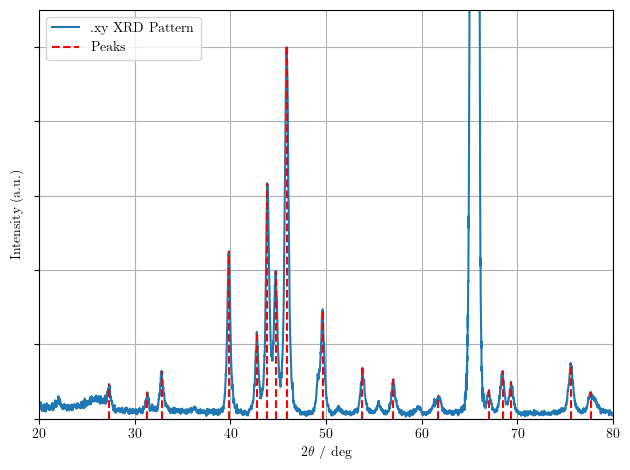

In [6]:
fig, ax = plt.subplots()

ax.plot(processed_data['Angle'], processed_data['intensity_norm'], label=f'{name} XRD Pattern')

plt.vlines(peak_angles.values, ymin=0, ymax=processed_data['intensity_norm'].iloc[peak_angles.index], color='red', linestyle='--', label='Peaks')
ax.axes.get_yaxis().set_ticklabels([])
plt.xlim(20, 80)
plt.ylim(0, 1.1)
plt.gca().set_ylim(bottom=0)
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}_bessel.pdf', dpi=500)
plt.show()

# expermamenting with auto labeling

In [7]:
def get_clean_reference_with_hkl(material_id, api_key, wavelength=1.5406, intensity_threshold=5):
    """Fetches structure from MP, calculates XRD, and returns 2theta, Intensity, and HKLs."""
    with MPRester(api_key) as mpr:
        docs = mpr.materials.summary.search(material_ids=[material_id], fields=["structure"])
        if not docs:
            raise ValueError(f"No material found for {material_id}")
        structure = docs[0].structure

    calculator = XRDCalculator(wavelength=wavelength)
    pattern = calculator.get_pattern(structure)
    
    x = np.array(pattern.x)
    y = np.array(pattern.y)
    hkl_list = pattern.hkls # Metadata containing Miller indices
    
    # Normalize theoretical intensity to 100
    y = 100 * y / np.max(y)
    
    clean_peaks = {"two_theta": [], "intensity": [], "hkl": []}

    for i in range(len(x)):
        if y[i] >= intensity_threshold:
            clean_peaks["two_theta"].append(x[i])
            clean_peaks["intensity"].append(y[i])
            # Store the first hkl tuple for this peak
            clean_peaks["hkl"].append(hkl_list[i][0]['hkl'])

    return clean_peaks

def auto_label_peaks(exp_peaks, ref_dict, tolerance=0.3):
    """Matches experimental peak positions to the best theoretical phase and HKL."""
    results = [] # Will store strings like "Ni (111)"

    for p_exp in exp_peaks:
        best_match = None
        highest_ref_int = -1
        
        for phase, data in ref_dict.items():
            ref_thetas = np.array(data['two_theta'])
            ref_intensities = np.array(data['intensity'])
            ref_hkls = data['hkl']
            
            diffs = np.abs(ref_thetas - p_exp)
            mask = diffs <= tolerance
            
            if np.any(mask):
                # Find the strongest theoretical peak within the tolerance
                idx = np.where(mask)[0][np.argmax(ref_intensities[mask])]
                current_max_int = ref_intensities[idx]
                
                if current_max_int > highest_ref_int:
                    highest_ref_int = current_max_int
                    hkl = ref_hkls[idx]
                    # Format as Phase (hkl)
                    best_match = f"{phase} ({hkl[0]}{hkl[1]}{hkl[2]})"
        
        results.append(best_match)
    return results

In [8]:
phase_targets = {
    "NiSi2 (Cubic)": "mp-2291",
    "NiSi (Cubic)":  "mp-1095177",
    "NiSi (Ortho)":  "mp-351",
    "Ni2Si (Ortho)": "mp-1118",
    "Ni2Si (Hex)": "mp-507",
    "Ni (Cubic)":    "mp-23",
    "Ni3Si2 (Ortho)": "mp-29667",
    "Ni31Si12 (Trigo)": "mp-27276"
    # "C": "mp-48"
}

# 1. Fetch all reference data
all_references = {}
for name, m_id in phase_targets.items():
    all_references[name] = get_clean_reference_with_hkl(m_id, API_KEY)

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

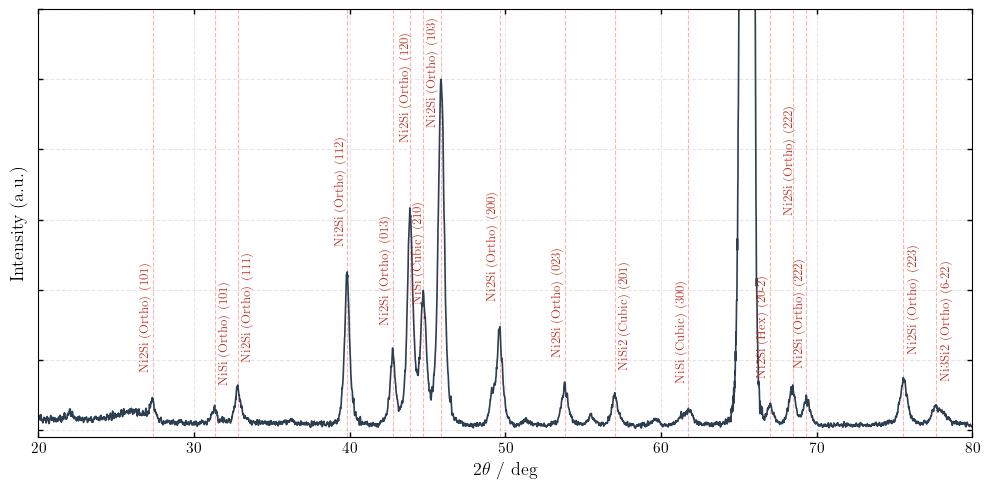

In [9]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 5))

# Plot experimental data
ax.plot(processed_data['Angle'], processed_data['intensity_norm'], 
        color='#2c3e50', lw=1.2, zorder=2)

# Identify labels for peaks
labels = auto_label_peaks(peak_angles, all_references, tolerance=0.6)
# labels[0] = 'C (Hex) (002)'

texts = []
for pos, label in zip(peak_angles, labels):
    if label:
        idx = np.abs(processed_data['Angle'] - pos).argmin()
        peak_height = processed_data['intensity_norm'].iloc[idx]
        
        ax.axvline(pos, color='red', linestyle='--', alpha=0.3, lw=0.8, zorder=1)
        
        t = ax.text(pos, peak_height + 0.02, label, 
                    rotation=90, fontsize=9, 
                    color='#c0392b', weight='bold',
                    va='bottom', ha='center')
        texts.append(t)

ax.set_ylim(-0.02, 1.2) 
adjust_text(texts, only_move={'points':'y', 'text':'xy'}, add_objects=[ax.lines[0]])


ax.set_yticklabels([])
# ax.set_xlim(10, 90)
ax.set_xlim(20, 80)
ax.set_ylim(-0.02, 1.2) # Increased upper limit to give labels room to breathe

ax.tick_params(axis='both', which='both', direction='in', 
                top=True, right=True, 
                width=1.0, labelsize=11)

ax.set_xlabel(r"$2\theta$ / deg", fontsize=13)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=13)
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)

plt.tight_layout()
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), name)}_labeled.pdf', dpi=300)
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), 'Ni_2Si_800')}_labeled.pdf', dpi=300)
plt.show()

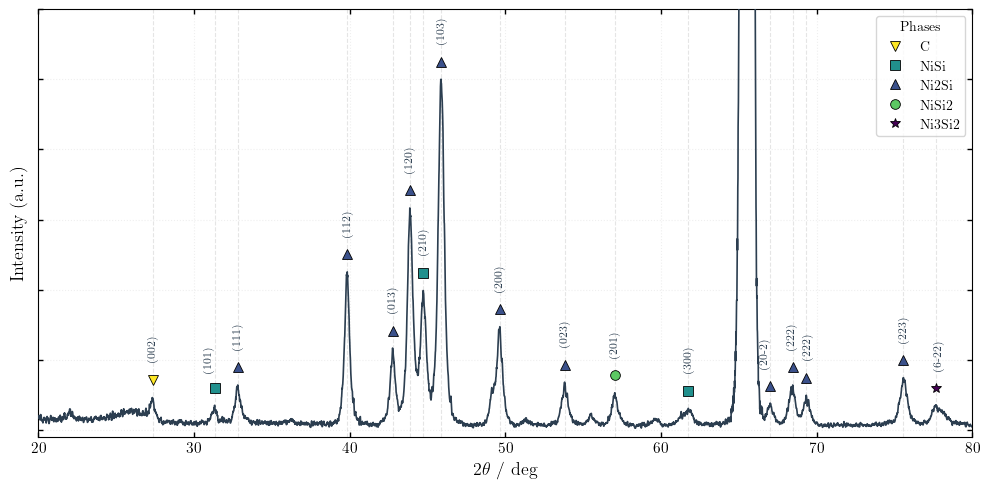

In [10]:
marker_map = {
    'C': 'v',            
    'NiSi2': 'o',     
    'NiSi': 's',       
    'Ni2Si': '^',     
    'Ni3Si2': '*',   
}

# Generate color map based on phases
phase_keys = list(marker_map.keys())
colors = plt.get_cmap('viridis_r')(np.linspace(0, 1, len(phase_keys)))
color_map = dict(zip(phase_keys, colors))

fig, ax = plt.subplots(figsize=(10, 5))

# Plot experimental data
ax.plot(processed_data['Angle'], processed_data['intensity_norm'], 
        color='#2c3e50', lw=1.2, zorder=3)

# Identify labels for peaks
labels = auto_label_peaks(peak_angles, all_references, tolerance=0.6)
labels[0] = 'C (002)'

texts = []
for pos, full_label in zip(peak_angles, labels):
    if full_label:
        # Extract Phase and HKL Phase (Structure) (hkl)
        phase = full_label.split('(')[0].strip()
        hkl = f"({full_label.split('(')[-1]}" 
        
        idx = np.abs(processed_data['Angle'] - pos).argmin()
        peak_height = processed_data['intensity_norm'].iloc[idx]
        
        ax.axvline(pos, color='gray', linestyle='--', alpha=0.2, lw=0.8, zorder=1)
        
        # Find matching phase in marker_map
        match = next((k for k in phase_keys if k in phase.replace('_', '').replace(' ', '')), None)
        
        if match:
            # Phase Marker
            ax.plot(pos, peak_height + 0.05, marker=marker_map[match], 
                    color=color_map[match], markersize=7, linestyle='None', 
                    markeredgecolor='black', markeredgewidth=0.6,
                    label=match, zorder=4)
        
            
            # hkl Text
            t = ax.text(pos, peak_height + 0.08, hkl, 
                        rotation=90, fontsize=8, 
                        color='#2c3e50', va='bottom', ha='center')
            texts.append(t)

# 4. Clean up the Legend (remove duplicates)
handles, legend_labels = ax.get_legend_handles_labels()
by_label = dict(zip(legend_labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Phases", 
          loc='upper right', frameon=True, fontsize=10)

ax.set_ylim(-0.02, 1.2)
# Adjust text to prevent overlapping
if texts:
    adjust_text(texts, only_move={'points':'y', 'text':'xy'}, add_objects=[ax.lines[0]])

# Final formatting
ax.set_xlim(20, 80)
ax.set_ylim(-0.02, 1.2)
ax.set_yticklabels([])
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, width=1.0, labelsize=11)
ax.set_xlabel(r"$2\theta$ / deg", fontsize=13)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=13)
ax.grid(True, linestyle=':', alpha=0.2, zorder=1)

plt.tight_layout()
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), 'Ni_2Si_890')}_markers.pdf', dpi=300)
plt.show()

In [14]:
# file_path_900 = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Si\Data\Stückchen\XRD\02182026_Ni2Si_900grad_.xy"

# data_900 = pd.read_csv(file_path_900, delimiter=" ", skiprows=1, header=None, names=['Angle', 'Intensity'])

# print(data_900.info())

# processed_data_900, peak_angles_900 = process_XRD_data(data_900, roi=False, baseline_params={'lam': 1e7, 'p': 0.0001, 'niter': 10}, peak_params={'prominence': 0.04, 'width': 5})


# marker_map = {
#     'C': 'v',            
#     'NiSi2': 'o',     
#     'NiSi': 's',       
#     'Ni2Si': '^',     
#     'Ni3Si2': '*',   
# }

# # Generate color map based on phases
# phase_keys = list(marker_map.keys())
# colors = plt.get_cmap('viridis_r')(np.linspace(0, 1, len(phase_keys)))
# color_map = dict(zip(phase_keys, colors))

# fig, ax = plt.subplots(figsize=(10, 5))

# # Plot experimental data

# ax.plot(processed_data_900['Angle'], processed_data_900['intensity_norm'] + 0.3, color="#000080", lw=1.2, zorder=2) # #D35400   000080

# ax.plot(processed_data['Angle'], processed_data['intensity_norm'], 
#         color='#2c3e50', lw=1.2, zorder=3)

# # Identify labels for peaks
# labels = auto_label_peaks(peak_angles, all_references, tolerance=0.6)
# labels[0] = 'C (002)'

# texts = []
# for pos, full_label in zip(peak_angles, labels):
#     if full_label:
#         # Extract Phase and HKL Phase (Structure) (hkl)
#         phase = full_label.split('(')[0].strip()
#         hkl = f"({full_label.split('(')[-1]}" 
        
#         # idx = np.abs(processed_data['Angle'] - pos).argmin()
#         # peak_height = processed_data['intensity_norm'].iloc[idx]
#         peak_height_900 = np.interp(pos, processed_data_900['Angle'], processed_data_900['intensity_norm'])
        
#         ax.axvline(pos, color='gray', linestyle='--', alpha=0.2, lw=0.8, zorder=1)
        
#         # Find matching phase in marker_map
#         match = next((k for k in phase_keys if k in phase.replace('_', '').replace(' ', '')), None)
        
#         if match:
#             # Phase Marker
#             ax.plot(pos, peak_height_900 + 0.35, marker=marker_map[match], 
#                     color=color_map[match], markersize=7, linestyle='None', 
#                     markeredgecolor='black', markeredgewidth=0.6,
#                     label=match, zorder=4)
        
            
#             # hkl Text
#             t = ax.text(pos, peak_height_900 + 0.38, hkl, 
#                         rotation=90, fontsize=8, 
#                         color='#2c3e50', va='bottom', ha='center')
#             texts.append(t)

# # 4. Clean up the Legend (remove duplicates)
# handles, legend_labels = ax.get_legend_handles_labels()
# by_label = dict(zip(legend_labels, handles))
# ax.legend(by_label.values(), by_label.keys(), title="Phases", 
#           loc='upper right', frameon=True, fontsize=10)

# ax.set_ylim(-0.02, 1.5)
# # Adjust text to prevent overlapping
# if texts:
#     adjust_text(texts, only_move={'points':'y', 'text':'xy'}, add_objects=[ax.lines[0]])

# ax.text(0.02, 0.28, '900°C', transform=ax.transAxes, fontsize=12, color='#000080')
# ax.text(0.02, 0.07, '800°C', transform=ax.transAxes, fontsize=12, color="#555555")

# # Final formatting
# ax.set_xlim(20, 80)
# ax.set_ylim(-0.02, 1.5)
# ax.set_yticklabels([])
# ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, width=1.0, labelsize=11)
# ax.set_xlabel(r"$2\theta$ / deg", fontsize=13)
# ax.set_ylabel(r"Intensity (a.u.)", fontsize=13)
# ax.grid(True, linestyle=':', alpha=0.2, zorder=1)

# plt.tight_layout()
# # plt.savefig(f'{os.path.join(os.path.dirname(file_path), 'Ni_2Si_890')}_markers_combined.pdf', dpi=300)
# plt.show()